# Solving the Black–Scholes Equation with Hermitian GQSP

This notebook demonstrates a quantum-assisted workflow for applying repeated inverse time steps of a discretised Black–Scholes operator. The non-Hermitian time-step matrix is first converted to a Hermitian matrix through a diagonal similarity transformation. Its spectrum is then mapped to $[-1,1]$, a polynomial approximation is constructed, and PennyLane's Generalised Quantum Signal Processing (GQSP) implementation is used to apply the polynomial transformation.

The notebook also includes classical validation, shot-based postselection, amplitude amplification and a Crank–Nicolson comparison.


## Notebook structure

1. Define the model and grid.
2. Construct and Hermitianise the implicit time-step matrix.
3. Rescale the spectrum and fit the inverse polynomial.
4. Validate the polynomial and construct the GQSP signal unitary.
5. Run shot-based GQSP and amplitude amplification.
6. Compare with Crank–Nicolson and analyse errors.

In [1]:
import numpy as np
import pennylane as qml
import time
from math import comb


# Make randomness reproducible
np.random.seed(13)

n_grid = 7          # number of data qubits
shots = 200_000_000  # number of measurement shots
deg = 20             # degree of the inverse-function polynomial


dtau = 0.01
T = 1                # maturity / total backward-time horizon


order_of_inv = 30    # Number of inverse timesteps needed to evolve back from maturity T
a = 0.35        # volatility
r = 0.02        # risk-free rate
K = 47          # strike price

## 1. Model parameters and asset-price grid

We discretise the asset-price coordinate on a uniform grid,

$$S_j = 1 + jh, \qquad j=0,\ldots,N-1,$$

where $N=2^{n_{\mathrm{grid}}}$ so that the grid can be represented by `n_grid` qubits. A smaller spacing $h$ resolves the asset-price domain more finely, but for fixed $N$ it also reduces the maximum represented asset price. Increasing the qubit count extends the grid, although it distributes a fixed number of measurement shots over more computational-basis states.

In [2]:
# Build the uniform asset-price grid.
N = 2**n_grid
h = 0.5
S = 1.0 + h * np.arange(N, dtype=float)


print("N =", N)
print("First 5 S values:", S[:5])
print("Last 5 S values:", S[-5:])

# Compute the finite-difference coefficients.
beta = (a**2 * S) / (2 * h**2)
alpha = (a**2 * S) / (2 * h**2) - (r * S) / h

print("\nSanity checks:")
print("min(beta) =", beta.min())
print("min(alpha) =", alpha.min())
print("alpha positive everywhere?", np.all(alpha > 0)) # needs to be positive for the diagonal D matrix to work

N = 128
First 5 S values: [1.  1.5 2.  2.5 3. ]
Last 5 S values: [62.5 63.  63.5 64.  64.5]

Sanity checks:
min(beta) = 0.24499999999999997
min(alpha) = 0.20499999999999996
alpha positive everywhere? True


## 2. Construct the discretised time-step matrix

The finite-difference discretisation gives a tridiagonal matrix $M$. The implicit time-step matrix is

$$\tilde{M}=I+M.$$

Small endpoint couplings are introduced where structural zeros would otherwise prevent the diagonal similarity transformation used in the next section.

In [3]:
# Build M, but replace the two structural zeros that block diagonal-similarity Hermitianisation by small epsilon entries.

eps_top = 1e-1  # regularised entry at (0, 1)
eps_bot = 1e-1  # regularised entry at (N-1, N-2)

# Build M (NxN)
M = np.zeros((N, N), dtype=float)

# First row from the paper
M[0, 0] = dtau * r
M[0, 1] = -dtau * eps_top

# Interior rows j = 1,...,N-2
for j in range(1, N - 1):
    M[j, j - 1] = -dtau * alpha[j]
    M[j, j]     = dtau * (alpha[j] + beta[j] + r)
    M[j, j + 1] = -dtau * beta[j]

M[N - 1, N - 2] = -dtau * eps_bot

# Build M_tilde = I + M
M_tilde = np.eye(N) + M

print("M shape:", M.shape)
print("M_tilde shape:", M_tilde.shape)
print("eps_top =", eps_top)
print("eps_bot =", eps_bot)

print("\nTop-left 5x5 of M:")
print(M[:5, :5])

print("\nBottom-right 5x5 of M:")
print(M[-5:, -5:])

kappa_M_tilde = np.linalg.cond(M_tilde)
M_tilde_inv = np.linalg.inv(M_tilde)
kappa_M_inv = np.linalg.cond(M_tilde_inv)

print("\nkappa(inv(M_tilde)) =", kappa_M_inv)
print("Condition number kappa(M_tilde) =", kappa_M_tilde)

M shape: (128, 128)
M_tilde shape: (128, 128)
eps_top = 0.1
eps_bot = 0.1

Top-left 5x5 of M:
[[ 0.0002   -0.001     0.        0.        0.      ]
 [-0.003075  0.00695  -0.003675  0.        0.      ]
 [ 0.       -0.0041    0.0092   -0.0049    0.      ]
 [ 0.        0.       -0.005125  0.01145  -0.006125]
 [ 0.        0.        0.       -0.00615   0.0137  ]]

Bottom-right 5x5 of M:
[[ 0.28145  -0.153125  0.        0.        0.      ]
 [-0.12915   0.2837   -0.15435   0.        0.      ]
 [ 0.       -0.130175  0.28595  -0.155575  0.      ]
 [ 0.        0.       -0.1312    0.2882   -0.1568  ]
 [ 0.        0.        0.       -0.001     0.      ]]

kappa(inv(M_tilde)) = 1.588505004124823
Condition number kappa(M_tilde) = 1.5885050041248239


## 3. Hermitianisation by diagonal similarity transformation

We construct a diagonal matrix $D=\operatorname{diag}(d)$ such that

$$H=D^{-1}\tilde{M}D$$

is symmetric (and therefore Hermitian, since the entries are real). The recurrence for the entries of $d$ is chosen so that corresponding upper- and lower-diagonal elements of $H$ agree.

In [4]:
# Build the diagonal vector d so that H = D^{-1} M_tilde D is symmetric.
# Because the first and last couplings are now eps_top and eps_bot,
# we must treat the endpoints separately.

d = np.ones(N, dtype=float)

# Pair (0,1)
d[1] = d[0] * np.sqrt(alpha[1] / eps_top)

# Interior pairs (j, j+1) for j = 1,...,N-3
for j in range(1, N - 2):
    ratio = alpha[j + 1] / beta[j]
    d[j + 1] = d[j] * np.sqrt(ratio)

# Final pair (N-2, N-1)
d[N - 1] = d[N - 2] * np.sqrt(eps_bot / beta[N - 2])

print("d shape:", d.shape)
print("d first 5:", d[:5])
print("d last 5:", d[-5:])
print("d min =", d.min())
print("d max =", d.max())

# Build H = D^{-1} M_tilde D using elementwise scaling
H = (M_tilde * d[None, :]) / d[:, None]

print("\nH shape:", H.shape)

# Check symmetry
sym_err = np.linalg.norm(H - H.T, ord=np.inf)
print("Symmetry check ||H - H^T||_inf =", sym_err)

print("\nTop-left 5x5 of H:")
print(H[:5, :5])

print("\nBottom-right 5x5 of H:")
print(H[-5:, -5:])

d shape: (128,)
d first 5: [1.         1.75356779 1.8521912  1.89423873 1.89810058]
d last 5: [2.14620557e-04 1.97104015e-04 1.81011409e-04 1.66227533e-04
 1.32748594e-05]
d min = 1.3274859448205973e-05
d max = 1.8981005845407188

H shape: (128, 128)
Symmetry check ||H - H^T||_inf = 5.551115123125783e-17

Top-left 5x5 of H:
[[ 1.0002     -0.00175357  0.          0.          0.        ]
 [-0.00175357  1.00695    -0.00388169  0.          0.        ]
 [ 0.         -0.00388169  1.0092     -0.00501124  0.        ]
 [ 0.          0.         -0.00501124  1.01145    -0.00613749]
 [ 0.          0.          0.         -0.00613749  1.0137    ]]

Bottom-right 5x5 of H:
[[ 1.28145    -0.1406275   0.          0.          0.        ]
 [-0.1406275   1.2837     -0.14174806  0.          0.        ]
 [ 0.         -0.14174806  1.28595    -0.14286861  0.        ]
 [ 0.          0.         -0.14286861  1.2882     -0.01252198]
 [ 0.          0.          0.         -0.01252198  1.        ]]


## 4. Map the Hermitian spectrum to $[-1,1]$

GQSP requires a signal operator whose eigenvalues lie in $[-1,1]$. If the eigenvalues of $H$ lie in $[\lambda_{\min},\lambda_{\max}]$, define

$$A=\frac{2H-(\lambda_{\max}+\lambda_{\min})I}{\lambda_{\max}-\lambda_{\min}}.$$

This affine transformation maps the spectrum of $H$ to $[-1,1]$. The inverse map is used when constructing the target polynomial.

In [5]:
# Compute the eigenvalues of the Hermitian matrix
eigvals_H = np.linalg.eigvalsh(H)

lam_min = float(eigvals_H.min())
lam_max = float(eigvals_H.max())

print("Eigenvalue range of H:")
print("lambda_min =", lam_min)
print("lambda_max =", lam_max)

# Safety check for inversion
if lam_min <= 0:
    raise ValueError("H has non-positive eigenvalues, so 1/x is singular on the spectrum.")

# Map H to A with spectrum in [-1, 1]
I = np.eye(N)
A = (2.0 * H - (lam_max + lam_min) * I) / (lam_max - lam_min)

# Check eigenvalues of A
eigvals_A = np.linalg.eigvalsh((A + A.T) / 2.0)

print("\nEigenvalue range of A (should be within [-1,1]):")
print("min eig(A) =", float(eigvals_A.min()))
print("max eig(A) =", float(eigvals_A.max()))

kappa_A = np.linalg.cond(A)
print(f"Condition number of A: {kappa_A}")

Eigenvalue range of H:
lambda_min = 0.999037664740549
lambda_max = 1.546543389622219

Eigenvalue range of A (should be within [-1,1]):
min eig(A) = -0.9999999999999997
max eig(A) = 0.9999999999999996
Condition number of A: 192.09887526268798


## 5. Polynomial approximation of repeated inverse time steps

The calculation applies `order_of_inv` inverse time steps, so the target scalar function is

$$g(x)=\left[\frac{\lambda_{\max}+\lambda_{\min}}{2}+\frac{\lambda_{\max}-\lambda_{\min}}{2}x\right]^{-m},$$

where $m=\texttt{order\_of\_inv}$. We fit this function in the Chebyshev basis and convert the result to the ordinary power basis required by the later matrix and GQSP calculations.

In [6]:
from numpy.polynomial import Chebyshev, Polynomial
import matplotlib.pyplot as plt
# Create a dense fitting grid on [-1, 1].
x_grid = np.linspace(-1, 1, 4001)

# Map x -> t in [lam_min, lam_max]
t_grid = (lam_max + lam_min) / 2.0 + (lam_max - lam_min) / 2.0 * x_grid #this undoes our mapping of H so we  can do 1/x

# Target function values: 1/t
y_grid = 1.0 / (t_grid)**order_of_inv

# Fit a Chebyshev polynomial to g(x) = 1 / t(x)^m.
cheb_coefs = np.polynomial.chebyshev.chebfit(x_grid, y_grid, deg)

# Make a Chebyshev polynomial object, then convert to power basis
p_cheb = Chebyshev(cheb_coefs, domain=[-1, 1])
p_pow = p_cheb.convert(kind=Polynomial)

# Power basis coefficients (ascending): c0, c1, ..., c5
p_coeffs = np.array(p_pow.coef, dtype=float)

print(f"Degree-{deg} polynomial coefficients p(x) in power basis (ascending):")
print(p_coeffs)
print("Degree actually returned:", len(p_coeffs) - 1)

Degree-20 polynomial coefficients p(x) in power basis (ascending):
[ 0.00071993 -0.00464529  0.01548625 -0.03553061  0.06304573 -0.09215995
  0.11563244 -0.12839352  0.12768536 -0.11319742  0.09508297 -0.08368158
  0.06118614 -0.02281948  0.01552133 -0.03604269  0.02141213  0.0089528
 -0.00483905 -0.00713378  0.00372039]
Degree actually returned: 20


### 5.1 Inspect the polynomial approximation

The following plots compare the exact target function with the Chebyshev approximation and its power-basis representation. The second plot shows the pointwise absolute error.

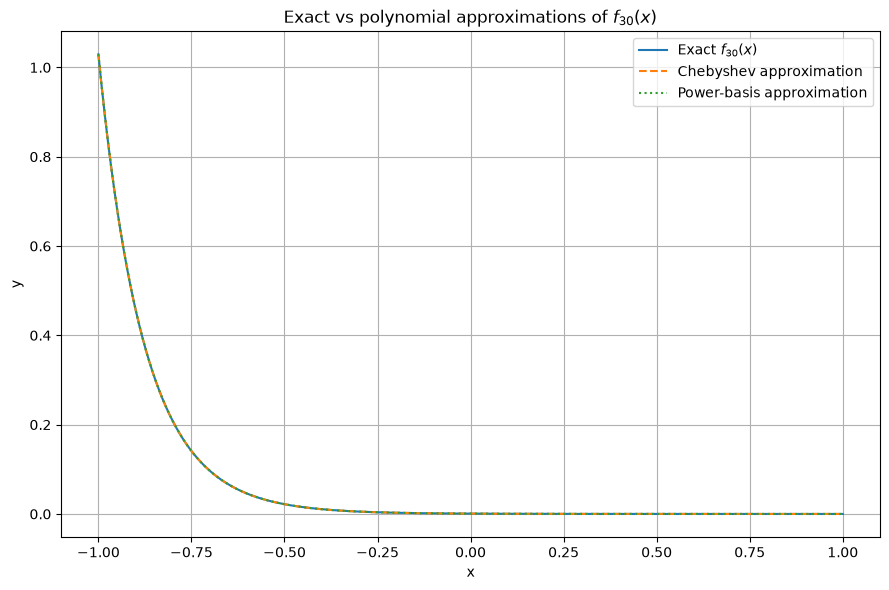

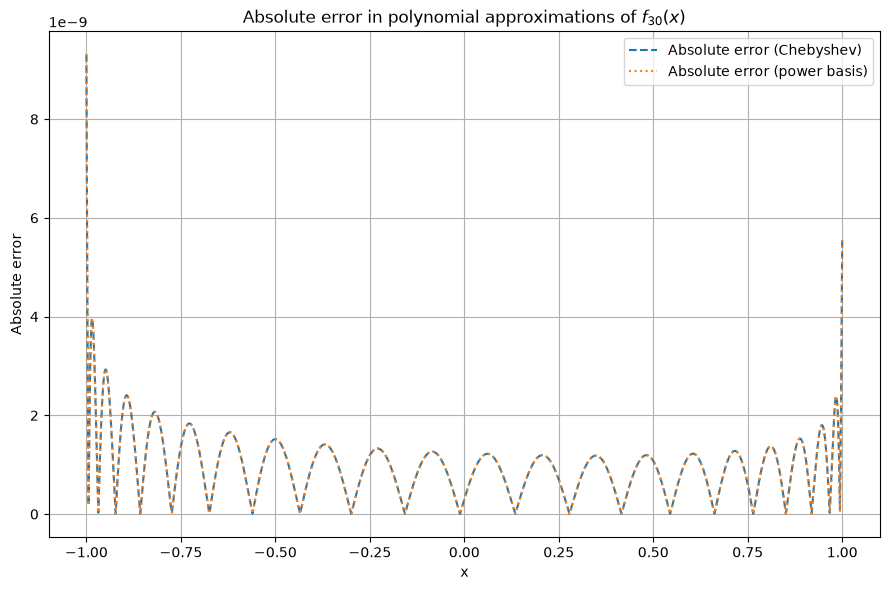

Power-basis polynomial degree: 20


In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Evaluate the three functions on the same x-grid

# Exact target function g(x) = 1 / t(x)^order_of_inv
y_exact = 1.0 / (t_grid ** order_of_inv)

# Chebyshev approximation evaluated directly in Chebyshev form
y_cheb = p_cheb(x_grid)

# Power-basis approximation evaluated using the converted polynomial
y_power = p_pow(x_grid)

# Absolute errors
abs_err_cheb = np.abs(y_exact - y_cheb)
abs_err_power = np.abs(y_exact - y_power)



plt.figure(figsize=(9, 6))
plt.plot(x_grid, y_exact, label=rf"Exact $f_{{{order_of_inv}}}(x)$")
plt.plot(x_grid, y_cheb, "--", label="Chebyshev approximation")
plt.plot(x_grid, y_power, ":", label="Power-basis approximation")

plt.xlabel("x")
plt.ylabel("y")
plt.title(rf"Exact vs polynomial approximations of $f_{{{order_of_inv}}}(x)$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 6))
plt.plot(x_grid, abs_err_cheb, "--", label="Absolute error (Chebyshev)")
plt.plot(x_grid, abs_err_power, ":", label="Absolute error (power basis)")

plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title(rf"Absolute error in polynomial approximations of $f_{{{order_of_inv}}}(x)$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Power-basis polynomial degree:", p_pow.degree())


### 5.2 Inspect the Chebyshev coefficients

The coefficient plots help assess whether the chosen polynomial degree is sufficient. Smoothly decaying coefficients generally indicate that the truncated expansion is resolving the target function well.

Number of Chebyshev coefficients: 21
Max |coefficient| = 0.2754867773176744
Min |coefficient| (nonzero) = 7.096073161650154e-09
Number of sign changes = 20

Chebyshev coefficients:
c[ 0] =  1.475706e-01
c[ 1] = -2.754868e-01
c[ 2] =  2.247333e-01
c[ 3] = -1.615029e-01
c[ 4] =  1.033116e-01
c[ 5] = -5.947542e-02
c[ 6] =  3.113904e-02
c[ 7] = -1.496955e-02
c[ 8] =  6.664112e-03
c[ 9] = -2.767899e-03
c[10] =  1.079614e-03
c[11] = -3.977162e-04
c[12] =  1.390699e-04
c[13] = -4.636002e-05
c[14] =  1.479075e-05
c[15] = -4.530977e-06
c[16] =  1.337158e-06
c[17] = -3.804419e-07
c[18] =  1.050025e-07
c[19] = -2.721320e-08
c[20] =  7.096073e-09


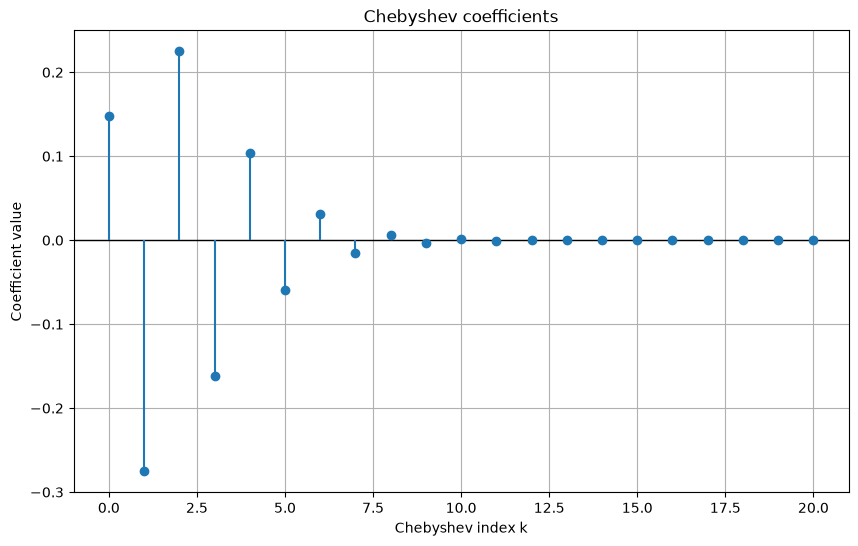

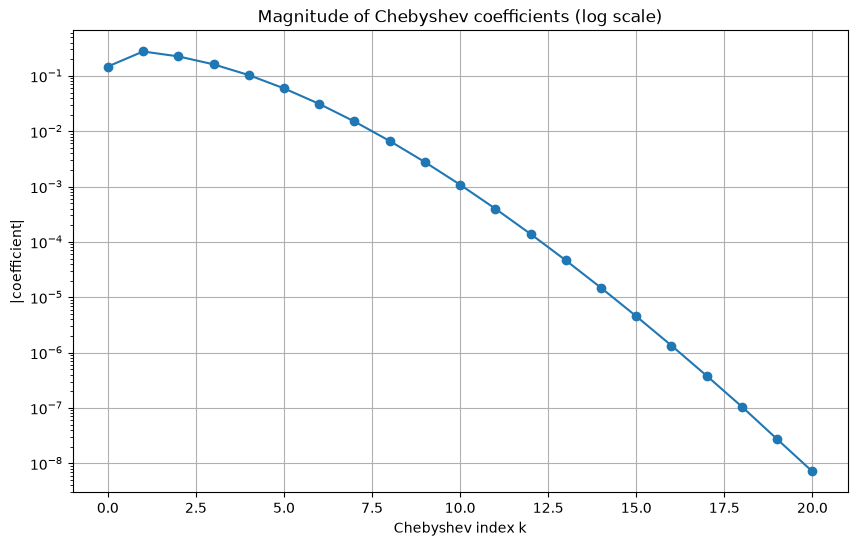

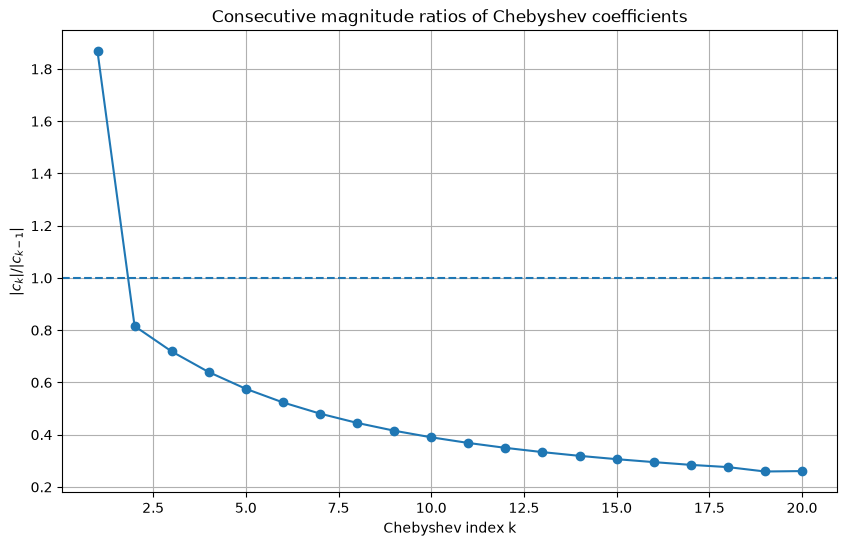

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# Plot the Chebyshev coefficients
k = np.arange(len(cheb_coefs))
coefs = np.array(cheb_coefs, dtype=float)

print("Number of Chebyshev coefficients:", len(coefs))
print("Max |coefficient| =", np.max(np.abs(coefs)))
print("Min |coefficient| (nonzero) =", np.min(np.abs(coefs[np.abs(coefs) > 0])))

# Basic sign-change count
signs = np.sign(coefs)
sign_changes = np.sum(signs[1:] * signs[:-1] < 0)
print("Number of sign changes =", sign_changes)

print("\nChebyshev coefficients:")
for i, c in enumerate(coefs):
    print(f"c[{i:2d}] = {c: .6e}")


# Plot coefficient values
plt.figure(figsize=(10, 6))
plt.axhline(0.0, color='black', linewidth=1)
plt.stem(k, coefs, basefmt=" ")
plt.xlabel("Chebyshev index k")
plt.ylabel("Coefficient value")
plt.title("Chebyshev coefficients")
plt.grid(True)
plt.show()


# Plot absolute values on a log scale
# This is useful for checking whether they decay smoothly
plt.figure(figsize=(10, 6))
plt.semilogy(k, np.abs(coefs), marker='o')
plt.xlabel("Chebyshev index k")
plt.ylabel("|coefficient|")
plt.title("Magnitude of Chebyshev coefficients (log scale)")
plt.grid(True)
plt.show()


# Plot consecutive coefficient ratios
eps = 1e-30
ratios = np.abs(coefs[1:]) / (np.abs(coefs[:-1]) + eps)

plt.figure(figsize=(10, 6))
plt.plot(k[1:], ratios, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Chebyshev index k")
plt.ylabel(r"$|c_k| / |c_{k-1}|$")
plt.title("Consecutive magnitude ratios of Chebyshev coefficients")
plt.grid(True)
plt.show()

## 6. Classical matrix-polynomial validation

Before constructing a quantum circuit, evaluate $p(A)$ classically and compare it with the exact repeated inverse of $H$. This isolates the polynomial-approximation error from the later quantum-circuit and sampling errors.

In [9]:
# Evaluate p(A) classically
A_complex = A.astype(complex)
I_complex = np.eye(N, dtype=complex)

pA_classical = np.zeros((N, N), dtype=complex)

# Horner loop: start from highest power
for k in range(len(p_coeffs) - 1, -1, -1):
    pA_classical = pA_classical @ A_complex + p_coeffs[k] * I_complex

print("p(A) shape:", pA_classical.shape)

# Exact repeated inverse of H
H_inv_exact = np.linalg.matrix_power(
    np.linalg.inv(H.astype(complex)), order_of_inv
)

# Compare p(A) with the exact repeated inverse.
err_inf = np.linalg.norm(pA_classical - H_inv_exact, ord=np.inf)
err_fro = np.linalg.norm(pA_classical - H_inv_exact, ord='fro')

print("\nClassical comparison on H^{-1}:")
print("  ||p(A) - H^{-1}||_inf =", err_inf)
print("  ||p(A) - H^{-1}||_F   =", err_fro)

p(A) shape: (128, 128)

Classical comparison on H^{-1}:
  ||p(A) - H^{-1}||_inf = 1.5996724077770435e-08
  ||p(A) - H^{-1}||_F   = 2.0944045326590004e-08


# GQSP only takes unitaries as inputs, so we must turn our Hermitian matrix into U and U^dagger in order to use GQSP

In [10]:
#Build sqrt(I - A^2)
A_complex = A.astype(complex)
I_complex = np.eye(N, dtype=complex)

A2 = A_complex @ A_complex
X = I_complex - A2

# Eigen-decomposition to compute sqrt(X)
eigvals_X, eigvecs_X = np.linalg.eigh((X + X.conj().T) / 2.0)
eigvals_X = np.clip(eigvals_X, 0.0, None)  # clip tiny negatives

sqrtX = (eigvecs_X * np.sqrt(eigvals_X)) @ eigvecs_X.conj().T

#Build U and check unitarity
U = A_complex + 1j * sqrtX
Udag = U.conj().T

unit_err = np.linalg.norm(Udag @ U - I_complex, ord=np.inf)
print("||U†U - I||_inf =", unit_err)

#Build V = diag(U, U^dagger)
# V is (2N x 2N)
zero_block = np.zeros((N, N), dtype=complex)
V = np.block([
    [U,        zero_block],
    [zero_block, Udag]
])

print("V shape:", V.shape)

||U†U - I||_inf = 2.544736508024613e-14
V shape: (256, 256)


## 8. Prepare the inverse polynomial for GQSP

The power-basis polynomial is converted into the Laurent-polynomial form required by PennyLane's GQSP routine. It is then scaled, when necessary, so that its magnitude on the unit circle satisfies the GQSP boundedness condition.

In [11]:
#Build R_n(z) coefficients in power basis
def Rn_coeffs_power_basis(n):
    # returns ascending coefficients for R_n(z)
    coeffs = np.zeros(n + 1, dtype=complex)

    if n == 0:
        coeffs[0] = 0.5
        return coeffs

    if n % 2 == 1:
        # odd n
        for k in range(0, (n - 1)//2 + 1):
            power = n - 2*k
            coeffs[power] += comb(n, k) / (2**n)
    else:
        # even n
        for k in range(0, n//2):
            power = n - 2*k
            coeffs[power] += comb(n, k) / (2**n)
        coeffs[0] += comb(n, n//2) / (2**(n+1))

    return coeffs

#Build P_hat(z) = sum c_n R_n(z)
P_hat_coeffs = np.zeros(deg + 1, dtype=complex)

for n_power in range(deg + 1):
    c_n = p_coeffs[n_power]
    Rn = Rn_coeffs_power_basis(n_power)  # coefficients for R_n

    # Add c_n * Rn into P_hat_coeffs (align degrees)
    for k in range(len(Rn)):
        P_hat_coeffs[k] += c_n * Rn[k]

print("P_hat coefficients (ascending):")
print(P_hat_coeffs)

#Estimate max |P_hat(e^{i theta})| on the unit circle
theta_grid = np.linspace(0, 2*np.pi, 8192, endpoint=False)
z_grid = np.exp(1j * theta_grid)

max_val = 0.0
for z in z_grid:
    val = 0.0 + 0.0j
    for k in range(len(P_hat_coeffs)):
        val += P_hat_coeffs[k] * (z ** k)
    max_val = max(max_val, abs(val))

kappa = max_val
print("\nEstimated max_{|z|=1} |P_hat(z)| =", kappa)

#Scale so it satisfies the unit circle rule
P_hat_scaled = P_hat_coeffs / kappa

# Quick re-check
max_val_scaled = 0.0
for z in z_grid:
    val = 0.0 + 0.0j
    for k in range(len(P_hat_scaled)):
        val += P_hat_scaled[k] * (z ** k)
    max_val_scaled = max(max_val_scaled, abs(val))

print("Estimated max_{|z|=1} |P_hat_scaled(z)| =", max_val_scaled)

P_hat coefficients (ascending):
[ 7.37853037e-02+0.j -1.37743389e-01+0.j  1.12366643e-01+0.j
 -8.07514316e-02+0.j  5.16558196e-02+0.j -2.97377084e-02+0.j
  1.55695222e-02+0.j -7.48477579e-03+0.j  3.33205620e-03+0.j
 -1.38394940e-03+0.j  5.39806909e-04+0.j -1.98858113e-04+0.j
  6.95349322e-05+0.j -2.31800077e-05+0.j  7.39537398e-06+0.j
 -2.26548869e-06+0.j  6.68578963e-07+0.j -1.90220939e-07+0.j
  5.25012252e-08+0.j -1.36065981e-08+0.j  3.54803658e-09+0.j]

Estimated max_{|z|=1} |P_hat(z)| = 0.5146525678227533
Estimated max_{|z|=1} |P_hat_scaled(z)| = 0.9999999999999998


## 10. Black–Scholes payoff workflow with amplitude amplification

We now apply the complete workflow to a European call payoff. The preprocessing $D^{-1}$ is performed classically before state preparation, while the circuit implements the polynomial transformation, the left multiplication by $D$, and coherent amplitude amplification of the successful ancilla branch.

The number of amplitude-amplification rounds is selected from the estimated base success probability and capped to prevent unbounded circuit depth.


Original input payoff state:
  strike K = 47
  payoff shape = (128,)
  ||psi|| = 1.0
  first 10 S values     = [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]
  first 10 payoff vals  = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  last 10 payoff vals   = [13.  13.5 14.  14.5 15.  15.5 16.  16.5 17.  17.5]


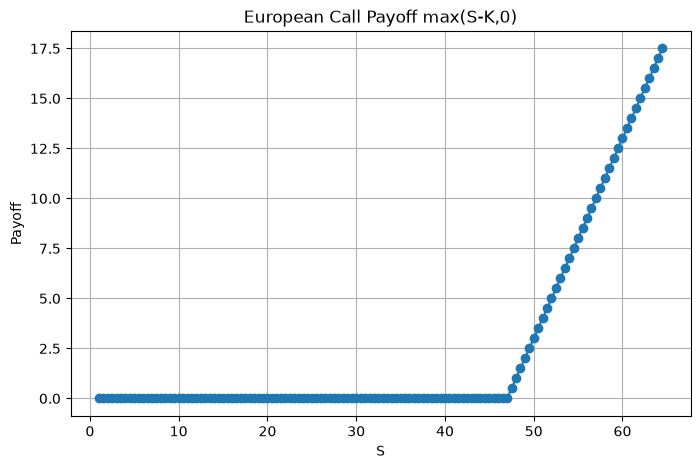

angles length: 3

Diagonal scaling:
  beta_D         = 1.8981005845407188
  min/max p_D    = 6.993759738722211e-06 1.0

Classically preprocessed input state:
  ||D^{-1} psi|| before renormalisation = 21896.461731964988
  ||psi_in|| after renormalisation      = 1.0

Unitary checks:
  unitarity error U_D+ = 9.992007221626409e-16
  unitarity error U_D- = 9.992007221626409e-16

Base ancilla success estimate (before OAA):
  p0 = 5.75789335833756e-10

Amplitude amplification choice:
  theta0                    = 2.3995610764143247e-05
  k_opt from formula        = 32730
  capped max rounds         = 1000
  using k_oaa               = 1000
  predicted success after OAA ~ 0.0023036899045113784


/opt/anaconda3/envs/bse-pawsey-python/lib/python3.11/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



Timing: shot-based amplified run took 106.359 seconds for 200000000 shots
samples shape: (200000000, 10)

Full postselection success from shots:
  kept shots               = 460735
  success probability ~    = 0.002303675
  discarded shots          = 199539265

Sampling diagnostics:
sum p_emp       = 1.0
max count bin   = 38156
argmax bin      = 127

Distribution comparisons (classical D^{-1}, shot-based D + GQSP + OAA):
TV(empirical, poly)        = 0.002532997029036639
TV(empirical, exact proxy) = 0.0025329969658179543
TV(poly, exact proxy)      = 5.256299147172521e-10

Original-state theory check:
  TV(full poly on psi, full exact on psi) = 5.25630148167284e-10

Matrix-level polynomial quality:
  ||Mtilde_inv_poly - Mtilde_inv_exact||_inf = 2.2421992392780796e-08


In [12]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import time


# Build European call payoff on the S-grid
payoff = np.maximum(S - K, 0.0).astype(float)

psi = payoff.astype(complex)
psi_norm = np.linalg.norm(psi)
if psi_norm == 0:
    raise ValueError("Payoff vector has zero norm. Choose a strike K inside the S-grid range.")
psi = psi / psi_norm

print("\nOriginal input payoff state:")
print("  strike K =", K)
print("  payoff shape =", payoff.shape)
print("  ||psi|| =", np.linalg.norm(psi))
print("  first 10 S values     =", S[:10])
print("  first 10 payoff vals  =", payoff[:10])
print("  last 10 payoff vals   =", payoff[-10:])

plt.figure(figsize=(8, 5))
plt.plot(S, payoff, marker="o")
plt.xlabel("S")
plt.ylabel("Payoff")
plt.title("European Call Payoff max(S-K,0)")
plt.grid(True)
plt.show()


# Convert polynomial to GQSP angles
angles = qml.poly_to_angles(P_hat_scaled, "GQSP")
print("angles length:", len(angles))


# Build D and D^{-1}
D = np.diag(d.astype(float))
Dinv = np.diag((1.0 / d).astype(float))

diag_D = np.real(np.diag(D)).astype(float)
beta_D = np.max(np.abs(diag_D))

if beta_D <= 0:
    raise ValueError("Invalid scaling for D")

# Scaled diagonal contraction in [-1, 1]
p_D = np.clip(diag_D / beta_D, -1.0, 1.0)

print("\nDiagonal scaling:")
print("  beta_D         =", beta_D)
print("  min/max p_D    =", p_D.min(), p_D.max())


# Apply D^{-1} CLASSICALLY to the input state
psi_pre = Dinv @ psi

psi_pre_norm = np.linalg.norm(psi_pre)
if psi_pre_norm == 0:
    raise ValueError("D^{-1} psi has zero norm, cannot prepare input state.")

psi_in = psi_pre / psi_pre_norm

print("\nClassically preprocessed input state:")
print("  ||D^{-1} psi|| before renormalisation =", psi_pre_norm)
print("  ||psi_in|| after renormalisation      =", np.linalg.norm(psi_in))


# Build the diagonal unitaries for D only
#   D_+- = exp(± i arccos(p_D))
# so that
#   (D_+ + D_-)/2 = p_D
theta_D = np.arccos(p_D)

D_plus_diag  = np.exp( 1j * theta_D)
D_minus_diag = np.exp(-1j * theta_D)

U_D_plus  = np.diag(D_plus_diag)
U_D_minus = np.diag(D_minus_diag)

print("\nUnitary checks:")
print("  unitarity error U_D+ =", np.linalg.norm(U_D_plus.conj().T @ U_D_plus - np.eye(N)))
print("  unitarity error U_D- =", np.linalg.norm(U_D_minus.conj().T @ U_D_minus - np.eye(N)))


# Wire layout
#   wire_a : branch ancilla for LEFT diagonal D
#   wire_c : GQSP control ancilla
#   wire_s : GQSP select ancilla
#   data_wires : system register
wire_a = 0
wire_c = 1
wire_s = 2
data_wires = list(range(3, 3 + n_grid))

all_wires = [wire_a, wire_c, wire_s] + data_wires
V_wires = [wire_s] + data_wires


# Devices
dev_exact = qml.device("default.qubit", wires=len(all_wires))
dev_shots = qml.device("default.qubit", wires=len(all_wires), shots=shots)


# Controlled application of the diagonal unitary pair for D
# If control = 0 apply the "+" branch
# If control = 1 apply the "-" branch
def apply_branch_pair(diag_plus, diag_minus, control_wire):
    qml.DiagonalQubitUnitary(diag_plus, wires=data_wires)
    relative = diag_minus / diag_plus
    qml.ctrl(qml.DiagonalQubitUnitary, control=control_wire)(relative, wires=data_wires)


# Main state-preparation block A
# This is the block whose success branch is a=0, c=0, s=0
def prepare_success_block(angles, psi_in):
    # Data input
    qml.AmplitudeEmbedding(psi_in, wires=data_wires, normalize=True)

    # Prepare branch ancilla for D in |+>
    qml.Hadamard(wires=wire_a)

    # Existing GQSP block for p(A)
    qml.Hadamard(wires=wire_s)
    qml.GQSP(qml.QubitUnitary(V, wires=V_wires), angles, control=wire_c)
    qml.Hadamard(wires=wire_s)

    # Left diagonal branch for D
    apply_branch_pair(D_plus_diag, D_minus_diag, wire_a)

    # Recombine the branch ancilla coherently
    qml.Hadamard(wires=wire_a)


# Phase flip on the "good" ancilla state |a,c,s> = |0,0,0>
# This marks the full success branch.
def oracle_good_success():
    qml.PauliX(wires=wire_a)
    qml.PauliX(wires=wire_c)
    qml.PauliX(wires=wire_s)

    # Controlled-Z on |111> after the X flips = phase flip on original |000>
    qml.ctrl(qml.PauliZ, control=[wire_a, wire_c], control_values=[1, 1])(wires=wire_s)

    qml.PauliX(wires=wire_s)
    qml.PauliX(wires=wire_c)
    qml.PauliX(wires=wire_a)


# Reflection about |0...0> on ALL wires
# This is used inside A S0 A^\dagger
def reflection_zero_all():
    for w in all_wires:
        qml.PauliX(wires=w)

    qml.ctrl(
        qml.PauliZ,
        control=all_wires[:-1],
        control_values=[1] * (len(all_wires) - 1)
    )(wires=all_wires[-1])

    for w in reversed(all_wires):
        qml.PauliX(wires=w)


# OAA iterate:
# Q = A S0 A^\dagger S_good
def one_oaa_round(angles, psi_in):
    oracle_good_success()
    qml.adjoint(prepare_success_block)(angles, psi_in)
    reflection_zero_all()
    prepare_success_block(angles, psi_in)


# Exact estimate of the BASE success probability p0
@qml.qnode(dev_exact)
def ancilla_probs_without_oaa(angles, psi_in):
    prepare_success_block(angles, psi_in)
    return qml.probs(wires=[wire_a, wire_c, wire_s])

anc_probs = ancilla_probs_without_oaa(angles, psi_in)
p0 = float(np.real_if_close(anc_probs[0]))   # probability of ancillas 000

print("\nBase ancilla success estimate (before OAA):")
print("  p0 =", p0)

if p0 <= 0:
    raise ValueError("Estimated base success probability is zero; OAA cannot be set automatically.")


# Choose near-optimal number of OAA rounds, then cap it
theta0 = np.arcsin(np.sqrt(np.clip(p0, 0.0, 1.0)))
k_opt_formula = int(np.floor(np.pi / (4 * theta0) - 0.5))

# Cap to avoid huge depth / overshoot
max_oaa_rounds = 1000
k_oaa = max(0, min(k_opt_formula, max_oaa_rounds))

p_pred = np.sin((2 * k_oaa + 1) * theta0) ** 2

print("\nAmplitude amplification choice:")
print("  theta0                    =", theta0)
print("  k_opt from formula        =", k_opt_formula)
print("  capped max rounds         =", max_oaa_rounds)
print("  using k_oaa               =", k_oaa)
print("  predicted success after OAA ~", p_pred)


# Shot-based amplified circuit
@qml.qnode(dev_shots)
def run_amplified_shots_classical_Dinv(angles, psi_in, k_oaa):
    # First prepare A|0>
    prepare_success_block(angles, psi_in)

    # Then apply k rounds of OAA
    for _ in range(k_oaa):
        one_oaa_round(angles, psi_in)

    # Measure all wires in the computational basis
    return qml.sample(wires=all_wires)


# Run shot simulation
t0 = time.perf_counter()
samples = run_amplified_shots_classical_Dinv(angles, psi_in, k_oaa)
t1 = time.perf_counter()

samples = np.array(samples)
print(f"\nTiming: shot-based amplified run took {t1 - t0:.3f} seconds for {shots} shots")
print("samples shape:", samples.shape)


# Postselect on FULL success:
# a = 0   -> LCU branch recombination for D succeeded
# c = 0, s = 0   -> GQSP success branch
mask_success = (
    (samples[:, wire_a] == 0) &
    (samples[:, wire_c] == 0) &
    (samples[:, wire_s] == 0)
)
samples_success = samples[mask_success]

kept = samples_success.shape[0]
p_succ = kept / shots

print("\nFull postselection success from shots:")
print("  kept shots               =", kept)
print("  success probability ~    =", p_succ)
print("  discarded shots          =", shots - kept)

if kept == 0:
    raise ValueError("No postselected shots kept. Increase shots or reduce the number of OAA rounds.")


# Build the conditional distribution on the data register
# after successful recombination and GQSP success
counts = np.zeros(N, dtype=int)

for row in samples_success:
    bits = row[data_wires]
    idx = 0
    for bit in bits:
        idx = (idx << 1) | int(bit)
    counts[idx] += 1

p_emp = counts / kept

print("\nSampling diagnostics:")
print("sum p_emp       =", p_emp.sum())
print("max count bin   =", counts.max())
print("argmax bin      =", np.argmax(counts))


# The quantum input is psi_in = normalised(D^{-1} psi),
# so we compare against the same normalised input.
Mtilde_inv_exact = np.linalg.inv(M_tilde)
Mtilde_inv100_exact = np.linalg.matrix_power(Mtilde_inv_exact, order_of_inv)

Mtilde_inv_poly = D @ pA_classical @ Dinv

y_poly = (D @ pA_classical) @ psi_in
H_inv = np.linalg.inv(H)
y_exact_proxy = (D @ np.linalg.matrix_power(H_inv, order_of_inv)) @ psi_in

def probs_from_vec(v):
    v = np.array(v, dtype=complex)
    norm = np.linalg.norm(v)
    if norm == 0:
        return np.ones(len(v)) / len(v)
    v = v / norm
    return np.abs(v) ** 2

p_poly = probs_from_vec(y_poly)
p_exact_proxy = probs_from_vec(y_exact_proxy)

tv_poly   = 0.5 * np.sum(np.abs(p_emp - p_poly))
tv_exact  = 0.5 * np.sum(np.abs(p_emp - p_exact_proxy))
tv_theory = 0.5 * np.sum(np.abs(p_poly - p_exact_proxy))

print("\nDistribution comparisons (classical D^{-1}, shot-based D + GQSP + OAA):")
print("TV(empirical, poly)        =", tv_poly)
print("TV(empirical, exact proxy) =", tv_exact)
print("TV(poly, exact proxy)      =", tv_theory)

# full operator comparison on the ORIGINAL psi
y_full_poly_on_original = (D @ pA_classical @ Dinv) @ psi
y_full_exact_on_original = Mtilde_inv100_exact @ psi

p_full_poly_on_original = probs_from_vec(y_full_poly_on_original)
p_full_exact_on_original = probs_from_vec(y_full_exact_on_original)

tv_full_theory = 0.5 * np.sum(np.abs(p_full_poly_on_original - p_full_exact_on_original))

print("\nOriginal-state theory check:")
print("  TV(full poly on psi, full exact on psi) =", tv_full_theory)

# Matrix-level polynomial quality
err_poly_inv = np.linalg.norm(Mtilde_inv_poly - Mtilde_inv100_exact, ord=np.inf)
print("\nMatrix-level polynomial quality:")
print("  ||Mtilde_inv_poly - Mtilde_inv_exact||_inf =", err_poly_inv)

# Keep named output vector for later plotting
y_quantum = np.sqrt(np.clip(p_emp, 0.0, None)).astype(complex)


## 11. Classical Crank–Nicolson reference solution

A Crank–Nicolson evolution is computed from the same spatial operator and terminal payoff. Separate variable names are used so that the classical reference calculation does not overwrite values from the quantum workflow.

Crank–Nicolson setup:
  CN dimension       = 128
  CN timestep count  = 30
  A_cn_mat shape     = (128, 128)
  B_cn_mat shape     = (128, 128)

Crank–Nicolson solve complete.
  y_cn_only shape = (128,)
  min(y_cn_only)  = 1.0568519484062627e-121
  max(y_cn_only)  = 18.016019872418426
  first 10 values = [1.05685195e-121 1.52070957e-118 5.95956904e-116 1.74764907e-113
 4.09035719e-111 7.95849234e-109 1.32392229e-106 1.92209634e-104
 2.47383677e-102 2.85763547e-100]
  last 10 values  = [13.28138608 13.78181295 14.28290748 14.78551064 15.29124197 15.80290641
 16.32483753 16.86294987 17.42428486 18.01601987]


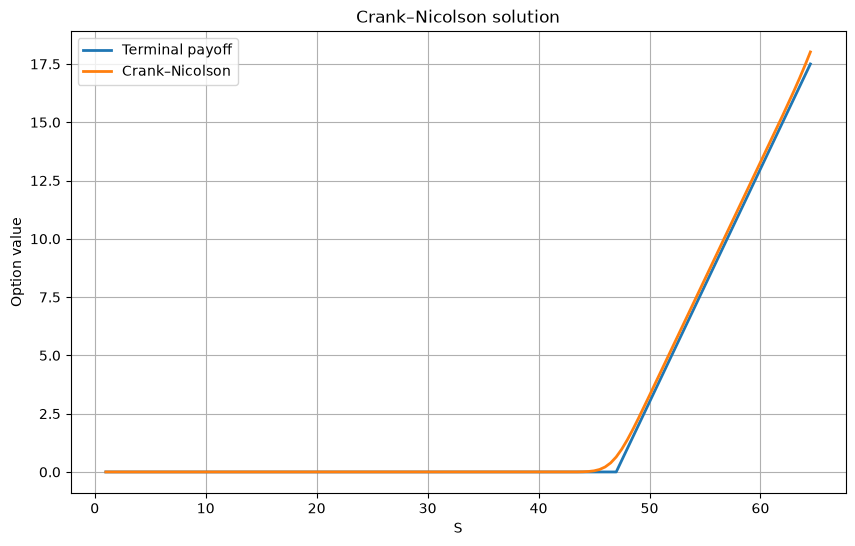

In [13]:
# Isolated Crank–Nicolson solve

import numpy as np
import matplotlib.pyplot as plt

# copy inputs into CN-specific names 
payoff_cn_input = payoff.astype(float).copy()
M_tilde_cn_input = M_tilde.copy()
S_cn_grid = S.copy()

num_cn_steps = int(order_of_inv)
N_cn_dim = M_tilde_cn_input.shape[0]
I_cn_mat = np.eye(N_cn_dim)

# Crank–Nicolson matrices built from the same operator
# If M_tilde = I + dtau*L, then:
#   (I + dtau/2 L) V^{n+1} = (I - dtau/2 L) V^n
# so in terms of M_tilde:
#   A = I + 0.5*(M_tilde - I)
#   B = I - 0.5*(M_tilde - I)

A_cn_mat = I_cn_mat + 0.5 * (M_tilde_cn_input - I_cn_mat)
B_cn_mat = I_cn_mat - 0.5 * (M_tilde_cn_input - I_cn_mat)

# terminal condition at maturity
V_cn_sol = payoff_cn_input.copy()

print("Crank–Nicolson setup:")
print("  CN dimension       =", N_cn_dim)
print("  CN timestep count  =", num_cn_steps)
print("  A_cn_mat shape     =", A_cn_mat.shape)
print("  B_cn_mat shape     =", B_cn_mat.shape)

# backward stepping
for cn_step_idx in range(num_cn_steps):
    rhs_cn_vec = B_cn_mat @ V_cn_sol
    V_cn_sol = np.linalg.solve(A_cn_mat, rhs_cn_vec)

# final CN solution
y_cn_only = V_cn_sol.copy()

print("\nCrank–Nicolson solve complete.")
print("  y_cn_only shape =", y_cn_only.shape)
print("  min(y_cn_only)  =", np.min(y_cn_only))
print("  max(y_cn_only)  =", np.max(y_cn_only))
print("  first 10 values =", y_cn_only[:10])
print("  last 10 values  =", y_cn_only[-10:])

# optional standalone CN plot
plt.figure(figsize=(10, 6))
plt.plot(S_cn_grid, payoff_cn_input, label="Terminal payoff", linewidth=2)
plt.plot(S_cn_grid, y_cn_only, label="Crank–Nicolson", linewidth=2)
plt.xlabel("S")
plt.ylabel("Option value")
plt.title("Crank–Nicolson solution")
plt.grid(True)
plt.legend()
plt.show()

### 11.1 Compare normalised output shapes

The sampled quantum output is first compared with the classical polynomial output using normalised computational-basis magnitudes.

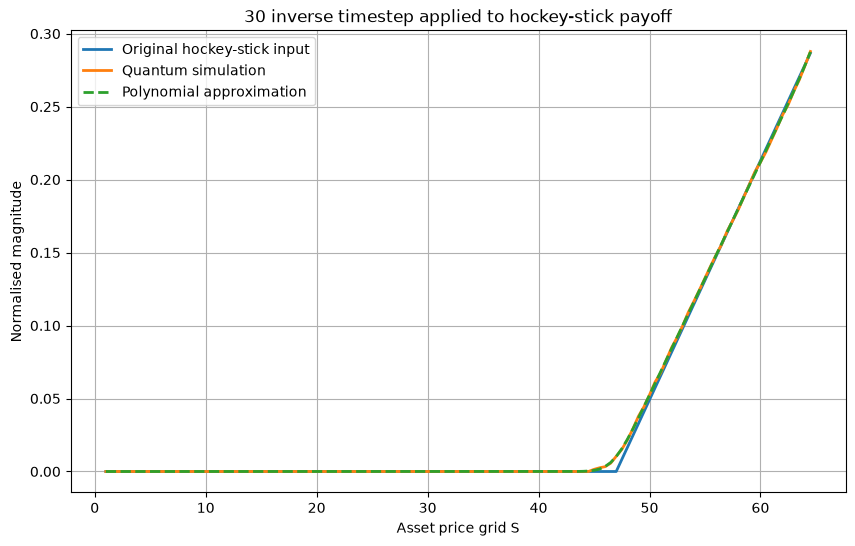

In [14]:
import matplotlib.pyplot as plt
import numpy as np


# Build normalised vectors for shape comparison


# Original input hockey-stick state (already normalised when built psi)
psi_plot = np.abs(psi)

# Quantum sampled output:
# p_emp is a probability distribution, so sqrt(p_emp) gives the magnitude of the normalised output state in the computational basis.
y_quantum_plot = np.sqrt(np.clip(p_emp, 0.0, None))

# Classical polynomial output, converted to normalised magnitude
y_poly_plot = np.abs(y_poly)
if np.linalg.norm(y_poly_plot) > 0:
    y_poly_plot = y_poly_plot / np.linalg.norm(y_poly_plot)

# Classical exact output, converted to normalised magnitude
y_exact_plot = np.abs(y_exact)
if np.linalg.norm(y_exact_plot) > 0:
    y_exact_plot = y_exact_plot / np.linalg.norm(y_exact_plot)


# Plot all curves on the S-grid
plt.figure(figsize=(10, 6))
plt.plot(S, psi_plot, label="Original hockey-stick input", linewidth=2)
plt.plot(S, y_quantum_plot, label="Quantum simulation", linewidth=2)
plt.plot(S, y_poly_plot, label="Polynomial approximation", linewidth=2, linestyle="--")



plt.xlabel("Asset price grid S")
plt.ylabel("Normalised magnitude")
plt.title(f"{order_of_inv} inverse timestep applied to hockey-stick payoff")
plt.legend()
plt.grid(True)
plt.show()

### 11.2 Restore option values in dollar units

The state-preparation normalisations are undone, and the sampled quantum output is scaled to the norm of the correctly rescaled exact output. The resulting curves are compared with the polynomial, exact inverse, and Crank–Nicolson solutions.

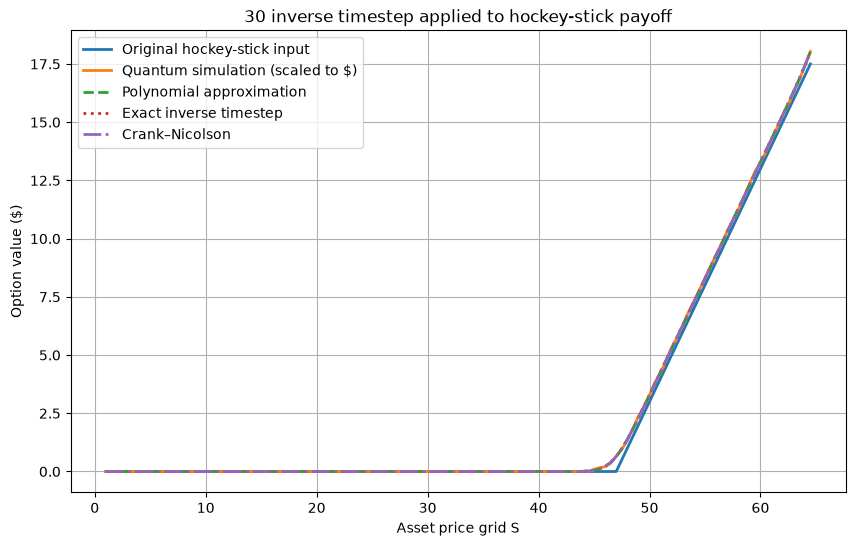

Scaling diagnostics:
  psi_norm                     = 61.053255441458646
  psi_pre_norm                 = 21896.461731964988
  full dollar rescale          = 1336850.2713857824
  ||y_exact_proxy||            = 4.688081736798051e-05
  ||y_exact in dollars||       = 62.67263342117204
  max |y_exact| in dollars     = 18.016254814025594
  max |y_poly| in dollars      = 18.016254650918405
  max quantum curve in dollars = 18.035731494249497
  max CN curve in dollars      = 18.016019872418426


In [15]:
import matplotlib.pyplot as plt
import numpy as np


# Correct dollar rescaling for the final quantum workflow

# Original payoff in dollars
payoff_plot_dollars = payoff.astype(float)

# Undo BOTH normalisations:
#   psi = payoff / psi_norm
#   psi_in = (D^{-1} psi) / psi_pre_norm
full_rescale_to_dollars = psi_norm * psi_pre_norm

# Classical outputs from the final workflow
y_poly_plot_dollars = full_rescale_to_dollars * np.abs(y_poly)
y_exact_plot_dollars = full_rescale_to_dollars * np.abs(y_exact_proxy)

# Quantum sampled output:
# sqrt(p_emp) is the magnitude of the normalised output state
quantum_output_shape = np.sqrt(np.clip(p_emp, 0.0, None))

# Scale the quantum shape to the norm of the correctly-scaled exact output
exact_output_norm_dollars = np.linalg.norm(y_exact_plot_dollars)
y_quantum_plot_dollars = exact_output_norm_dollars * quantum_output_shape

# Crank–Nicolson is already in dollars
y_cn_plot_dollars = y_cn_only.copy()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S, payoff_plot_dollars, label="Original hockey-stick input", linewidth=2)
plt.plot(S, y_quantum_plot_dollars, label="Quantum simulation (scaled to $)", linewidth=2)
plt.plot(S, y_poly_plot_dollars, label="Polynomial approximation", linewidth=2, linestyle="--")
plt.plot(S, y_exact_plot_dollars, label="Exact inverse timestep", linewidth=2, linestyle=":")
plt.plot(S_cn_grid, y_cn_plot_dollars, label="Crank–Nicolson", linewidth=2, linestyle="-.")

plt.xlabel("Asset price grid S")
plt.ylabel("Option value ($)")
plt.title(f"{order_of_inv} inverse timestep applied to hockey-stick payoff")
plt.legend()
plt.grid(True)
plt.show()

print("Scaling diagnostics:")
print("  psi_norm                     =", psi_norm)
print("  psi_pre_norm                 =", psi_pre_norm)
print("  full dollar rescale          =", full_rescale_to_dollars)
print("  ||y_exact_proxy||            =", np.linalg.norm(y_exact_proxy))
print("  ||y_exact in dollars||       =", exact_output_norm_dollars)
print("  max |y_exact| in dollars     =", np.max(y_exact_plot_dollars))
print("  max |y_poly| in dollars      =", np.max(y_poly_plot_dollars))
print("  max quantum curve in dollars =", np.max(y_quantum_plot_dollars))
print("  max CN curve in dollars      =", np.max(y_cn_plot_dollars))

## 12. Error analysis relative to Crank–Nicolson


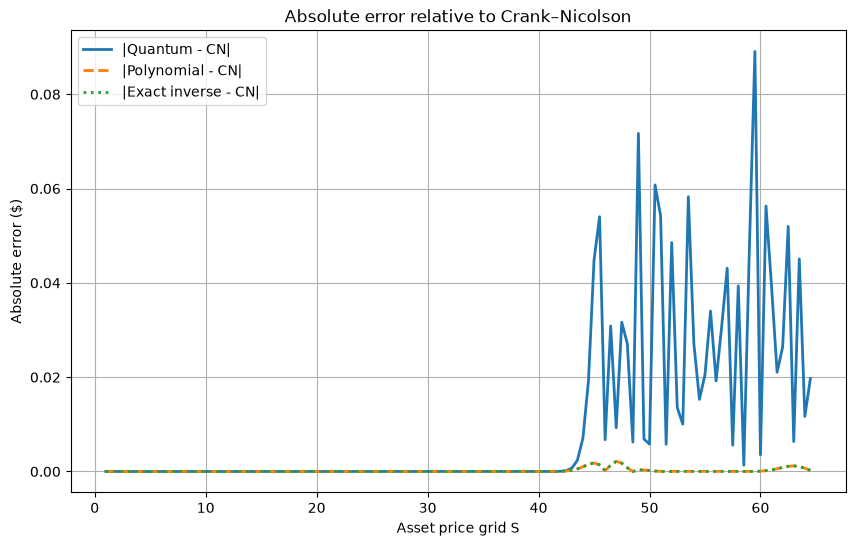

Max absolute errors against Crank–Nicolson:
  Quantum      = 0.08907082589587567
  Polynomial   = 0.002142282794048045
  Exact inverse= 0.0021422361727690964


In [16]:
import matplotlib.pyplot as plt
import numpy as np


# Absolute error against Crank–Nicolson (in dollar units)

# Rebuild the same dollar-scaled curves 
payoff_plot_dollars = payoff.astype(float)

# Undo both normalisations from the final workflow
full_rescale_to_dollars = psi_norm * psi_pre_norm

# Classical outputs in dollars
y_poly_plot_dollars = full_rescale_to_dollars * np.abs(y_poly)
y_exact_plot_dollars = full_rescale_to_dollars * np.abs(y_exact_proxy)

# Quantum output in dollars
quantum_output_shape = np.sqrt(np.clip(p_emp, 0.0, None))
exact_output_norm_dollars = np.linalg.norm(y_exact_plot_dollars)
y_quantum_plot_dollars = exact_output_norm_dollars * quantum_output_shape

# Crank–Nicolson reference
y_cn_plot_dollars = y_cn_only.copy()

# Absolute errors relative to Crank–Nicolson
err_quantum_cn = np.abs(y_quantum_plot_dollars - y_cn_plot_dollars)
err_poly_cn = np.abs(y_poly_plot_dollars    - y_cn_plot_dollars)
err_exact_cn = np.abs(y_exact_plot_dollars   - y_cn_plot_dollars)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S_cn_grid, err_quantum_cn, label="|Quantum - CN|", linewidth=2)
plt.plot(S_cn_grid, err_poly_cn, label="|Polynomial - CN|", linewidth=2, linestyle="--")
plt.plot(S_cn_grid, err_exact_cn, label="|Exact inverse - CN|", linewidth=2, linestyle=":")

plt.xlabel("Asset price grid S")
plt.ylabel("Absolute error ($)")
plt.title("Absolute error relative to Crank–Nicolson")
plt.legend()
plt.grid(True)
plt.show()

print("Max absolute errors against Crank–Nicolson:")
print("  Quantum      =", np.max(err_quantum_cn))
print("  Polynomial   =", np.max(err_poly_cn))
print("  Exact inverse=", np.max(err_exact_cn))